Nama : Naufal Oktariliano Najwan Akbar

NPM : 25083010014

Kelas : A

# BAGIAN 1 - IMPORT FILE CSV DAN LIBRARY

In [1]:
from google.colab import files

uploaded = files.upload()

Saving sintesis_data_donat_harian.csv to sintesis_data_donat_harian.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# BAGIAN 2 - MEMBACA DATASET

In [7]:
df = pd.read_csv("sintesis_data_donat_harian.csv")

df.head(10)

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333
5,2026-01-06,Gerai A,25000,90,2250000,765000,1683333,-198333
6,2026-01-07,Gerai A,25000,85,2125000,722500,1683333,-280833
7,2026-01-08,Gerai A,25000,87,2175000,739500,1683333,-247833
8,2026-01-09,Gerai A,25000,84,2100000,714000,1683333,-297333
9,2026-01-10,Gerai A,25000,119,2975000,1011500,1683333,280167


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tanggal                 450 non-null    object
 1   Gerai                   450 non-null    object
 2   Harga Jual (Rp)         450 non-null    int64 
 3   Jumlah Terjual (Unit)   450 non-null    int64 
 4   Pendapatan Kotor (Rp)   450 non-null    int64 
 5   Biaya Variabel (Rp)     450 non-null    int64 
 6   Fixed Cost Harian (Rp)  450 non-null    int64 
 7   Balance (Rp)            450 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 28.3+ KB


In [9]:
df.describe()

,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
count,450.000000,450.000000,4.500000e+02,4.500000e+02,4.500000e+02,4.500000e+02
mean,15800.000000,266.402222,3.342420e+06,1.427089e+06,1.523333e+06,3.919975e+05
std,6119.085481,160.911187,8.660617e+05,5.392152e+05,7.113147e+05,8.492523e+05
min,8000.000000,81.000000,2.025000e+06,6.885000e+05,7.333330e+05,-1.348266e+06
25%,11000.000000,127.250000,2.596250e+06,9.860000e+05,8.000000e+05,-2.364530e+05
50%,15000.000000,221.500000,3.262500e+06,1.327730e+06,1.683333e+06,3.131670e+05
75%,20000.000000,384.500000,4.015750e+06,1.866800e+06,1.733333e+06,1.132530e+06
max,25000.000000,710.000000,5.742000e+06,2.953600e+06,2.666666e+06,2.088400e+06


# BAGIAN 3 - MENGECEK DATA

In [10]:
print("Jumlah data:", len(df))
print("\nJumlah data per gerai:")
print(df["Gerai"].value_counts())

print("\nMissing value:")
print(df.isnull().sum())

Jumlah data: 450

Jumlah data per gerai:
Gerai
Gerai A    90
Gerai B    90
Gerai C    90
Gerai D    90
Gerai E    90
Name: count, dtype: int64

Missing value:
Tanggal                   0
Gerai                     0
Harga Jual (Rp)           0
Jumlah Terjual (Unit)     0
Pendapatan Kotor (Rp)     0
Biaya Variabel (Rp)       0
Fixed Cost Harian (Rp)    0
Balance (Rp)              0
dtype: int64


# BAGIAN 4 - PLOT JUMLAH PENJUALAN DAN REVENUE

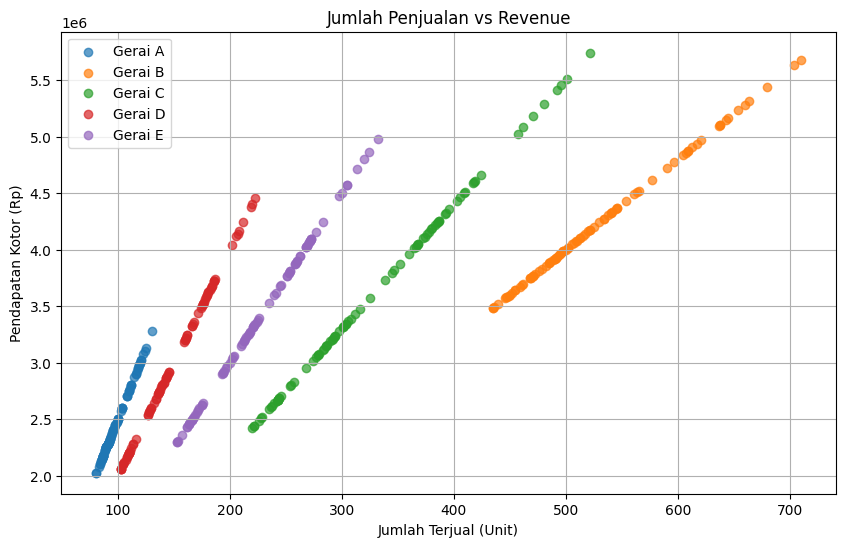

In [11]:
plt.figure(figsize=(10, 6))

for gerai in sorted(df["Gerai"].unique()):
    data = df[df["Gerai"] == gerai]

    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"],
        label=gerai,
        alpha=0.7
    )

plt.xlabel("Jumlah Terjual (Unit)")
plt.ylabel("Pendapatan Kotor (Rp)")
plt.title("Jumlah Penjualan vs Revenue")
plt.legend()
plt.grid(True)
plt.show()

**PENJELASAN**

Berdasarkan scatter plot, terlihat adanya hubungan positif antara jumlah penjualan dengan pendapatan kotor pada kelima gerai. Ketika jumlah unit yang terjual meningkat, pendapatan kotor juga mengalami peningkatan. Pola titik pada masing-masing gerai cenderung membentuk garis lurus, sehingga hubungan antara kedua variabel dapat diasumsikan bersifat linear. Perbedaan posisi dan kemiringan antar-gerai menunjukkan adanya perbedaan harga jual serta strategi pemasaran yang digunakan oleh masing-masing gerai. Oleh karena itu, regresi linear digunakan untuk memodelkan hubungan antara jumlah penjualan dan revenue.

# BAGIAN 5 - REGRESI REVENUE

In [13]:
hasil_regresi_revenue = []

for gerai in sorted(df["Gerai"].unique()):

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_
    r2 = model.score(X, y)

    hasil_regresi_revenue.append({
        "Gerai": gerai,
        "Koefisien a": a,
        "Intercept b": b,
        "R²": r2
    })

hasil_revenue = pd.DataFrame(hasil_regresi_revenue)

hasil_revenue

,Gerai,Koefisien a,Intercept b,R²
0,Gerai A,25000.0,-4.656613e-10,1.0
1,Gerai B,8000.0,0.000000e+00,1.0
2,Gerai C,11000.0,4.656613e-10,1.0
3,Gerai D,20000.0,-9.313226e-10,1.0
4,Gerai E,15000.0,-4.656613e-10,1.0


**PENJELASAN**

Kode ini digunakan untuk melihat hubungan antara jumlah donat yang terjual dengan pendapatan (revenue) pada masing-masing gerai. Sederhananya, program ingin mengetahui “jika jumlah donat yang terjual bertambah, maka revenue bertambah berapa?” Program akan mengecek Gerai A sampai Gerai E satu per satu. Dalam regresi ini, Jumlah Terjual (Unit) digunakan sebagai X, sedangkan Pendapatan Kotor (Rp) digunakan sebagai Y. Selanjutnya, program membuat garis regresi untuk melihat pola hubungan antara jumlah penjualan dan revenue.

Hasil regresi ditampilkan dalam tiga bagian utama, yaitu Koefisien (a), Intercept (b), dan R². Bagian yang paling mudah dibaca adalah Koefisien (a) karena menunjukkan tambahan revenue setiap ada 1 donat yang terjual. Contohnya, Gerai A memiliki koefisien 25.000, artinya setiap tambahan 1 donat yang terjual akan menambah revenue sekitar Rp25.000. Gerai B memiliki koefisien 8.000, Gerai C 11.000, Gerai D 20.000, dan Gerai E 15.000. Sementara itu, Intercept (b) menunjukkan perkiraan revenue ketika penjualan berada pada 0 unit. Pada hasil tersebut nilainya sangat dekat dengan 0, sehingga secara sederhana dapat dianggap Rp0.

Selanjutnya, R² menunjukkan seberapa sesuai garis regresi dengan data yang digunakan. Pada semua gerai, nilai R² = 1,0, yang berarti data jumlah penjualan dan revenue pada dataset ini memiliki hubungan linear yang sangat tepat. Jadi, cara membaca tabelnya dapat disederhanakan menjadi: Koefisien = tambahan revenue untuk setiap 1 donat, Intercept = revenue saat penjualan 0, dan R² = tingkat kecocokan hubungan antara penjualan dan revenue. Hasil regresi ini kemudian menjadi dasar untuk tahap berikutnya, yaitu mencari jumlah donat yang harus terjual agar setiap gerai mencapai breakeven point (titik tidak untung dan tidak rugi).

# BAGIAN 6 - VISUALISASI GARIS REGRESI

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


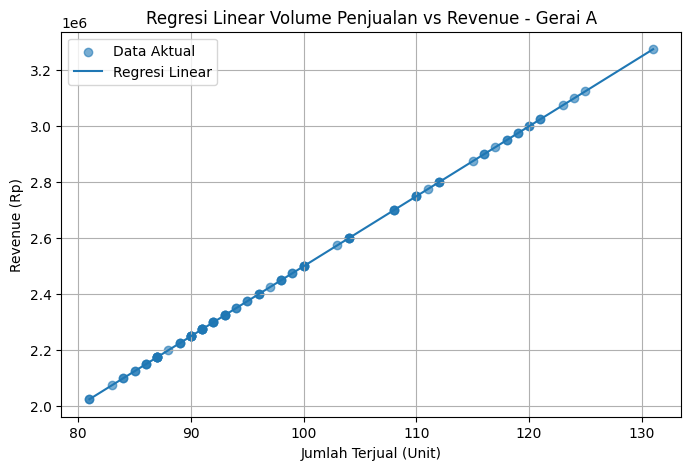

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


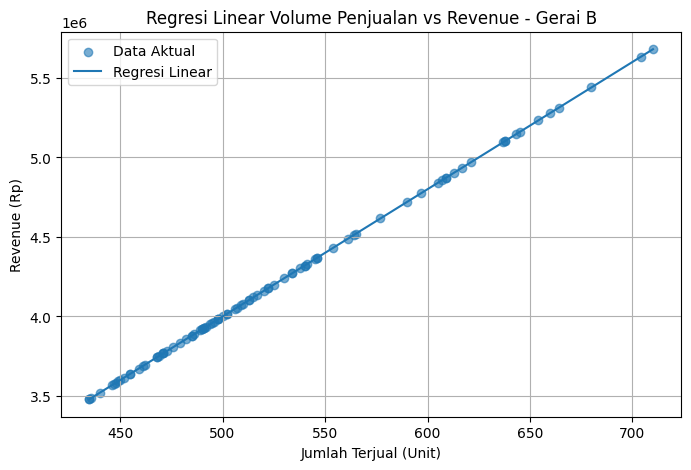

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


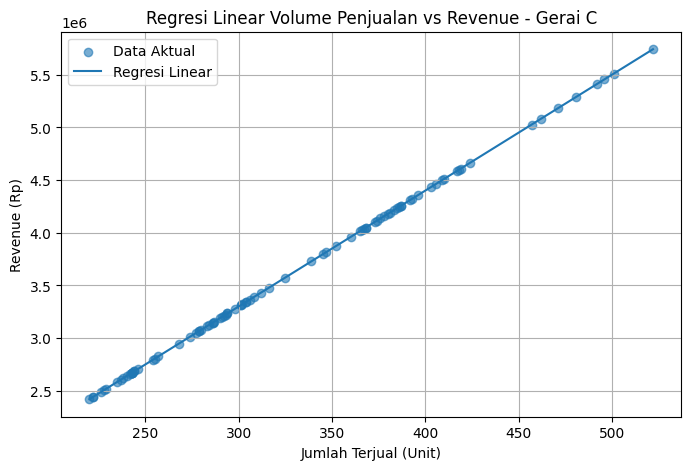

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


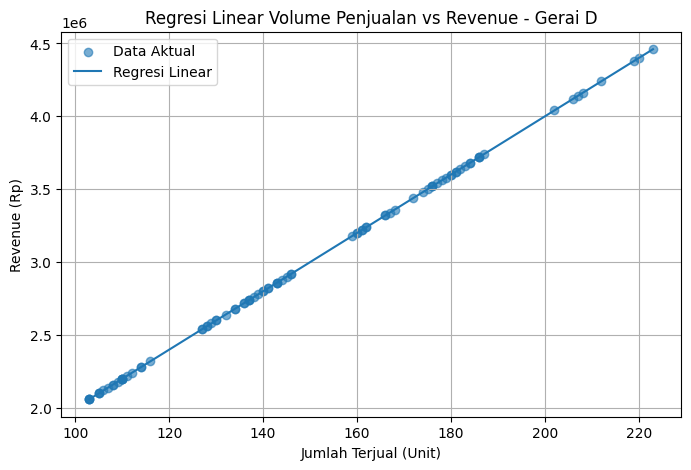

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


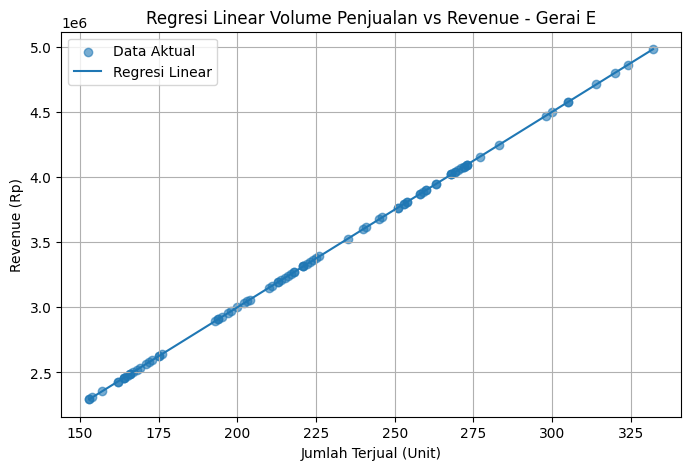

In [14]:
for gerai in sorted(df["Gerai"].unique()):

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    x_line = np.linspace(
        data["Jumlah Terjual (Unit)"].min(),
        data["Jumlah Terjual (Unit)"].max(),
        100
    ).reshape(-1, 1)

    y_line = model.predict(x_line)

    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, alpha=0.6, label="Data Aktual")
    plt.plot(x_line, y_line, label="Regresi Linear")

    plt.xlabel("Jumlah Terjual (Unit)")
    plt.ylabel("Revenue (Rp)")
    plt.title(f"Regresi Linear Volume Penjualan vs Revenue - {gerai}")
    plt.legend()
    plt.grid(True)
    plt.show()

**PENJELASAN**

Kode ini digunakan untuk membuat grafik hubungan antara jumlah donat yang terjual dan revenue pada setiap gerai. Titik-titik pada grafik menunjukkan data penjualan yang sebenarnya, sedangkan garis regresi menunjukkan pola hubungan antara jumlah penjualan dan revenue. Grafik dibuat secara terpisah untuk setiap gerai, mulai dari Gerai A hingga Gerai E, sehingga pola masing-masing gerai dapat dilihat dengan lebih jelas.

Cara membacanya cukup sederhana. Sumbu X menunjukkan jumlah donat yang terjual, sedangkan sumbu Y menunjukkan revenue. Jika garis grafik bergerak naik ke arah kanan, berarti terdapat hubungan positif, yaitu semakin banyak donat yang terjual, semakin besar revenue yang diperoleh. Dari grafik yang dihasilkan, Gerai A, B, dan C menunjukkan pola yang meningkat ke atas, dan Gerai D serta E juga memiliki pola yang sama.

Dengan demikian, grafik menunjukkan bahwa volume penjualan memiliki hubungan positif dengan revenue pada kelima gerai. Titik-titik data yang berada sangat dekat dengan garis regresi menunjukkan bahwa model linear cukup sesuai untuk menggambarkan hubungan tersebut. Hasil regresi ini selanjutnya dapat digunakan sebagai dasar untuk menghitung jumlah penjualan yang diperlukan untuk mencapai breakeven point, yaitu kondisi ketika pendapatan sudah dapat menutupi biaya.

# BAGIAN 7 — MENENTUKAN FUNGSI BREAKEVEN

In [15]:
hasil_breakeven = []

for gerai in sorted(df["Gerai"].unique()):

    # Mengambil data gerai
    data = df[df["Gerai"] == gerai]

    # Mengambil hasil regresi dari Bagian 5
    hasil = hasil_revenue[hasil_revenue["Gerai"] == gerai].iloc[0]

    a = hasil["Koefisien a"]
    b = hasil["Intercept b"]

    # Menghitung rata-rata biaya variabel per unit
    biaya_variabel_per_unit = (
        data["Biaya Variabel (Rp)"] / data["Jumlah Terjual (Unit)"]
    ).mean()

    # Mengambil rata-rata fixed cost harian
    fixed_cost = data["Fixed Cost Harian (Rp)"].mean()

    # Menyimpan hasil
    hasil_breakeven.append({
        "Gerai": gerai,
        "Koefisien Revenue": a,
        "Intercept Revenue": b,
        "Biaya Variabel per Unit": biaya_variabel_per_unit,
        "Fixed Cost Harian": fixed_cost
    })

hasil_breakeven = pd.DataFrame(hasil_breakeven)

hasil_breakeven

,Gerai,Koefisien Revenue,Intercept Revenue,Biaya Variabel per Unit,Fixed Cost Harian
0,Gerai A,25000.0,-4.656613e-10,8500.0,1683333.0
1,Gerai B,8000.0,0.000000e+00,4160.0,733333.0
2,Gerai C,11000.0,4.656613e-10,4840.0,1733333.0
3,Gerai D,20000.0,-9.313226e-10,7200.0,2666666.0
4,Gerai E,15000.0,-4.656613e-10,6300.0,800000.0


**PENJELASAN**

Kode pada Bagian 7 bertujuan untuk menyiapkan data yang diperlukan dalam menentukan breakeven point setiap gerai. Program mengambil hasil regresi revenue dari Bagian 5, kemudian menggabungkannya dengan biaya variabel per unit dan fixed cost harian dari dataset. Perulangan for digunakan agar proses dilakukan secara otomatis untuk Gerai A sampai Gerai E. Biaya variabel per unit dihitung dari perbandingan biaya variabel dengan jumlah produk yang terjual, sedangkan fixed cost diperoleh dari rata-rata biaya tetap harian. Seluruh hasil tersebut kemudian disimpan dalam DataFrame bernama hasil_breakeven agar lebih mudah digunakan pada tahap selanjutnya. Dari hasil program, misalnya Gerai A memiliki koefisien revenue sebesar Rp25.000 per unit, biaya variabel sebesar Rp8.500 per unit, dan fixed cost harian sebesar Rp1.683.333. Data ini nantinya digunakan untuk membentuk fungsi laba, yang kemudian dicari nilai penjualannya saat laba sama dengan nol sebagai titik breakeven.

**BAGIAN 8 - MEMBENTUK FUNGSI LABA**

In [16]:
hasil_laba = []

for gerai in sorted(hasil_breakeven["Gerai"].unique()):

    data = hasil_breakeven[hasil_breakeven["Gerai"] == gerai].iloc[0]

    a = data["Koefisien Revenue"]
    b = data["Intercept Revenue"]
    biaya_variabel = data["Biaya Variabel per Unit"]
    fixed_cost = data["Fixed Cost Harian"]

    # Fungsi laba:
    # Laba(x) = Revenue(x) - Biaya Variabel(x) - Fixed Cost

    koefisien_laba = a - biaya_variabel
    konstanta_laba = b - fixed_cost

    hasil_laba.append({
        "Gerai": gerai,
        "Koefisien Laba": koefisien_laba,
        "Konstanta Laba": konstanta_laba
    })

hasil_laba = pd.DataFrame(hasil_laba)

hasil_laba

,Gerai,Koefisien Laba,Konstanta Laba
0,Gerai A,16500.0,-1683333.0
1,Gerai B,3840.0,-733333.0
2,Gerai C,6160.0,-1733333.0
3,Gerai D,12800.0,-2666666.0
4,Gerai E,8700.0,-800000.0


**PENJELASAN**

Pada Bagian 8, kita mulai membentuk fungsi laba berdasarkan hasil regresi dan data biaya yang sudah diperoleh pada Bagian 7. Tujuannya adalah mengetahui hubungan antara jumlah donat yang terjual dengan laba yang diperoleh setiap gerai. Fungsi laba diperoleh dari revenue dikurangi biaya variabel dan fixed cost. Fungsi ini nantinya digunakan untuk mencari kondisi ketika laba bernilai nol, yaitu titik breakeven.

Kode tersebut menggunakan hasil dari Bagian 7 untuk membentuk fungsi laba setiap gerai. Koefisien laba diperoleh dari koefisien revenue dikurangi biaya variabel per unit, sedangkan konstanta laba diperoleh dari intercept revenue dikurangi fixed cost. Dengan demikian, fungsi laba dapat ditulis dalam bentuk \(Laba(x)=ax+b\). Fungsi ini nantinya menjadi fungsi yang akan dicari akarnya, yaitu ketika laba = 0, sehingga diperoleh jumlah penjualan pada titik breakeven.


**PENJELASAN HASIL**


Tabel tersebut menunjukkan koefisien dan konstanta dari fungsi laba masing-masing gerai. Misalnya pada Gerai A, fungsi labanya adalah \(L(x)=16.500x-1.683.333\), yang berarti setiap tambahan satu unit penjualan memberikan tambahan laba sebesar Rp16.500 setelah dikurangi biaya variabel, sementara Rp1.683.333 merupakan fixed cost yang harus ditutup. Hasil untuk Gerai B, C, D, dan E juga menunjukkan pola yang sama.

**BAGIAN 9 - METODE BISECTION UNTUK MENCARI BREAKEVEN**

In [17]:
# BAGIAN 9 - METODE BISECTION UNTUK MENCARI BREAKEVEN

def bisection(f, a, b, tol=1e-6, max_iter=100):
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        return None

    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        if abs(fc) < tol:
            return c

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    return (a + b) / 2


hasil_breakeven_akhir = []

for gerai in hasil_laba["Gerai"]:

    data = hasil_laba[hasil_laba["Gerai"] == gerai].iloc[0]

    koefisien = data["Koefisien Laba"]
    konstanta = data["Konstanta Laba"]

    # Membentuk fungsi laba
    fungsi_laba = lambda x: koefisien * x + konstanta

    # Mencari titik breakeven
    bep = bisection(fungsi_laba, 0, 1000)

    hasil_breakeven_akhir.append({
        "Gerai": gerai,
        "Breakeven (Unit)": bep
    })

hasil_breakeven_akhir = pd.DataFrame(hasil_breakeven_akhir)

hasil_breakeven_akhir

,Gerai,Breakeven (Unit)
0,Gerai A,102.020182
1,Gerai B,190.972135
2,Gerai C,281.385227
3,Gerai D,208.333281
4,Gerai E,91.954023


**PENJELASAN**

Pada Bagian 9, kita mulai mencari jumlah penjualan saat laba = 0 menggunakan metode Bisection. Karena titik breakeven merupakan akar dari fungsi laba, program akan mencari nilai \(x\) yang membuat \(L(x)\) mendekati nol. Kita gunakan batas awal 0 dan 1000 unit, kemudian metode Bisection akan membagi interval tersebut menjadi dua secara berulang sampai diperoleh hasil yang cukup mendekati titik breakeven.

Kode tersebut menggunakan metode Bisection untuk mencari akar dari fungsi laba setiap gerai. Fungsi bisection() bekerja dengan membagi interval pencarian menjadi dua bagian secara berulang hingga nilai fungsi laba mendekati nol. Pada program ini, interval awal yang digunakan adalah 0 sampai 1000 unit. Setelah proses selesai, program menghasilkan jumlah unit penjualan yang diperlukan agar setiap gerai mencapai kondisi breakeven, yaitu ketika pendapatan sudah dapat menutupi seluruh biaya sehingga laba sama dengan nol.

**PENJELASAN HASIL**

Berdasarkan hasil metode Bisection, diperoleh jumlah penjualan yang diperlukan oleh masing-masing gerai untuk mencapai titik breakeven, yaitu kondisi ketika laba bernilai nol. Gerai A mencapai breakeven pada sekitar 102,02 unit, Gerai B pada 190,97 unit, Gerai C pada 281,39 unit, Gerai D pada 208,33 unit, dan Gerai E pada 91,95 unit. Nilai tersebut menunjukkan perkiraan jumlah produk yang harus terjual agar pendapatan gerai dapat menutupi biaya variabel dan biaya tetap yang dikeluarkan. Secara praktis, karena jumlah produk merupakan bilangan bulat, hasil tersebut dapat dibulatkan ke atas sehingga masing-masing gerai perlu menjual sekitar 103 unit, 191 unit, 282 unit, 209 unit, dan 92 unit untuk mencapai atau melewati titik breakeven.

# BAGIAN 10 - VISUALISASI TITIK BREAKEVEN

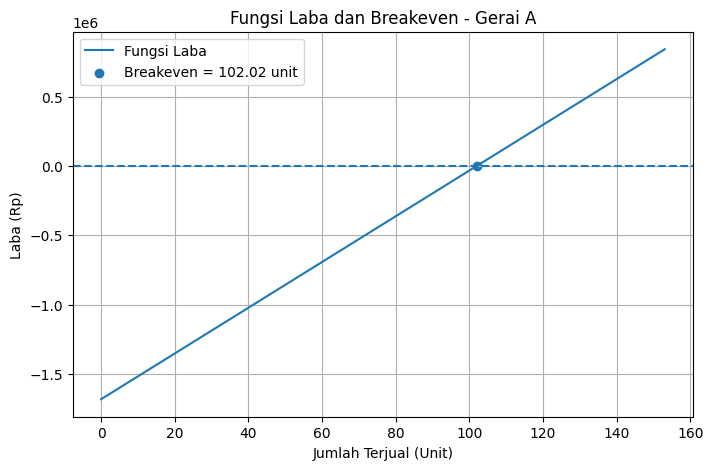

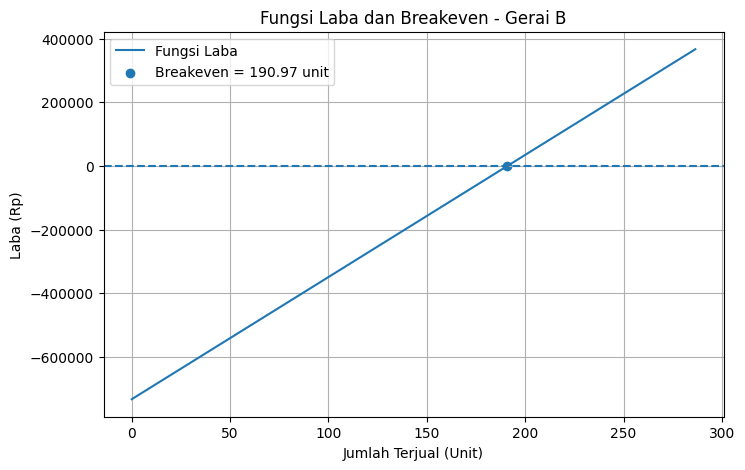

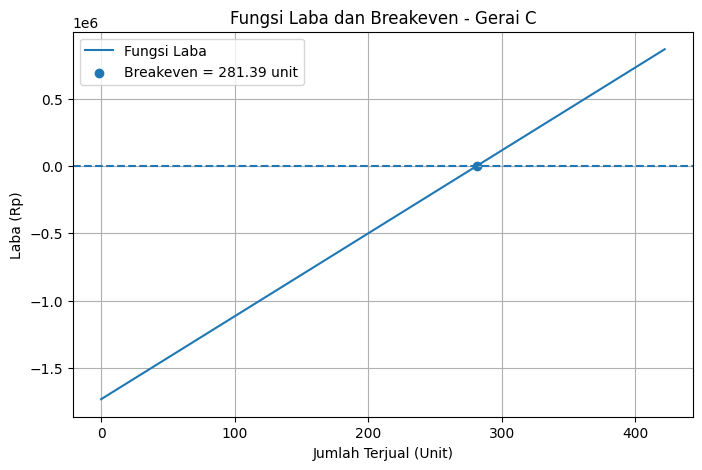

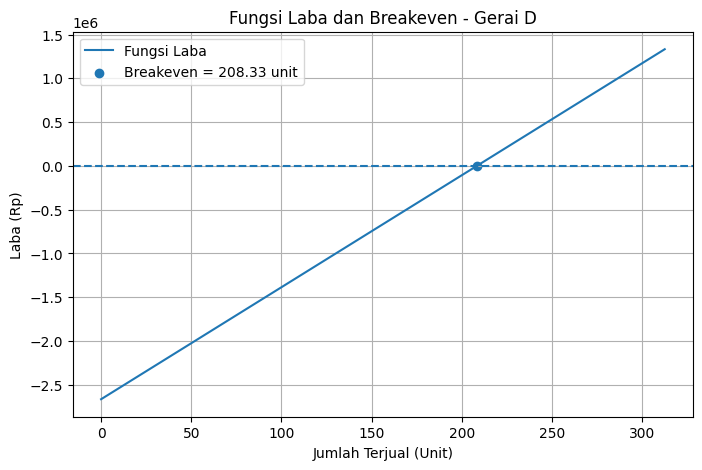

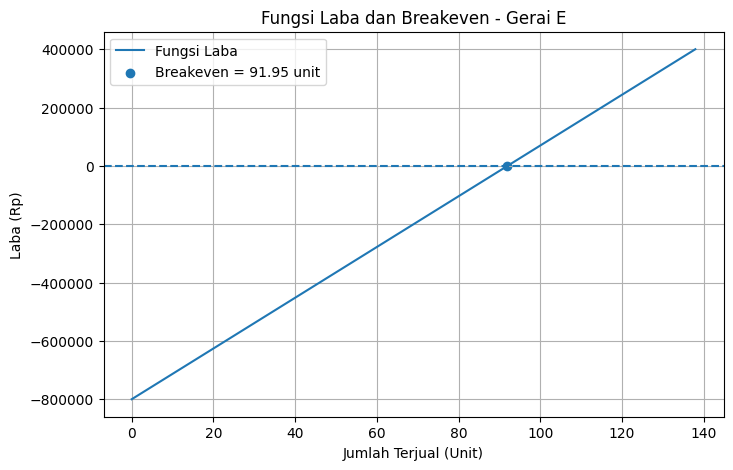

In [18]:
# BAGIAN 10 - VISUALISASI TITIK BREAKEVEN

for gerai in hasil_laba["Gerai"]:

    data = hasil_laba[hasil_laba["Gerai"] == gerai].iloc[0]

    koefisien = data["Koefisien Laba"]
    konstanta = data["Konstanta Laba"]

    bep = hasil_breakeven_akhir[
        hasil_breakeven_akhir["Gerai"] == gerai
    ]["Breakeven (Unit)"].iloc[0]

    # Membuat rentang jumlah penjualan
    x = np.linspace(0, bep * 1.5, 100)

    # Menghitung laba
    y = koefisien * x + konstanta

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label="Fungsi Laba")
    plt.scatter(bep, 0, label=f"Breakeven = {bep:.2f} unit")

    plt.axhline(0, linestyle="--")
    plt.xlabel("Jumlah Terjual (Unit)")
    plt.ylabel("Laba (Rp)")
    plt.title(f"Fungsi Laba dan Breakeven - {gerai}")
    plt.legend()
    plt.grid(True)
    plt.show()

**PENJELASAN**

Tujuannya adalah menampilkan hubungan antara jumlah penjualan dan laba, sekaligus menunjukkan posisi titik breakeven untuk masing-masing gerai. Dengan grafik ini, hasil perhitungan dari metode Bisection dapat dilihat secara lebih jelas.

Kode tersebut membuat grafik fungsi laba untuk setiap gerai berdasarkan hasil perhitungan sebelumnya. Sumbu horizontal menunjukkan jumlah produk yang terjual, sedangkan sumbu vertikal menunjukkan laba. Titik pada garis \(y=0\) menunjukkan posisi breakeven, yaitu ketika laba sama dengan nol. Dengan demikian, grafik ini digunakan untuk memvisualisasikan hasil metode Bisection dan memperlihatkan jumlah penjualan yang diperlukan setiap gerai untuk mencapai kondisi impas.

**PENJELASAN HASIL**

Secara keseluruhan, hasil analisis menunjukkan bahwa setiap gerai memiliki hubungan yang berbeda antara jumlah penjualan, revenue, dan biaya. Hasil regresi sebelumnya menunjukkan bahwa revenue meningkat secara linear seiring bertambahnya jumlah produk yang terjual, dengan nilai \(R^2=1\) pada seluruh gerai. Setelah mempertimbangkan biaya variabel dan fixed cost, diperoleh fungsi laba untuk masing-masing gerai. Fungsi tersebut kemudian digunakan dalam metode Bisection untuk mencari jumlah penjualan ketika laba sama dengan nol.

Berdasarkan hasil perhitungan, Gerai A mencapai titik breakeven pada sekitar 102,02 unit, Gerai B pada 190,97 unit, Gerai C pada 281,39 unit, Gerai D pada 208,33 unit, dan Gerai E pada 91,95 unit. Artinya, secara matematis jumlah penjualan tersebut merupakan titik ketika pendapatan telah menutupi biaya variabel dan fixed cost. Karena jumlah produk yang dijual berupa bilangan bulat, hasil tersebut dapat dibulatkan ke atas menjadi masing-masing 103 unit untuk A, 191 unit untuk B, 282 unit untuk C, 209 unit untuk D, dan 92 unit untuk E.

Dari hasil tersebut juga terlihat bahwa kebutuhan volume penjualan tiap gerai berbeda karena perbedaan revenue per unit, biaya variabel per unit, dan fixed cost. Dalam konteks perhitungan ini, hasil breakeven bukan sekadar menunjukkan jumlah penjualan, tetapi juga menunjukkan seberapa besar volume penjualan yang diperlukan untuk menutup seluruh biaya operasional berdasarkan model regresi yang digunakan.

### Kesimpulan

Berdasarkan hasil analisis yang telah dilakukan, dapat disimpulkan bahwa metode regresi linear dapat digunakan untuk mengetahui hubungan antara jumlah penjualan dan pendapatan kotor pada masing-masing gerai. Hasil regresi menunjukkan hubungan yang sangat baik antara jumlah produk yang terjual dengan revenue, yang ditunjukkan oleh nilai \(R^2 = 1\) pada seluruh gerai. Selanjutnya, hasil regresi tersebut digunakan untuk membentuk fungsi laba dengan mempertimbangkan biaya variabel dan fixed cost harian.

Pencarian titik breakeven dilakukan menggunakan metode Bisection dengan mencari nilai jumlah penjualan ketika fungsi laba bernilai nol. Hasilnya menunjukkan bahwa Gerai A mencapai breakeven pada sekitar 102,02 unit, Gerai B pada 190,97 unit, Gerai C pada 281,39 unit, Gerai D pada 208,33 unit, dan Gerai E pada 91,95 unit. Dalam penerapan praktis, nilai tersebut dapat dibulatkan ke atas menjadi 103, 191, 282, 209, dan 92 unit. Dengan demikian, analisis regresi dan metode Bisection dapat digunakan secara bersama-sama untuk menentukan perkiraan volume penjualan yang diperlukan setiap gerai agar dapat mencapai kondisi titik balik modal.
